# 04 SMOTE on work_type, repair, final files (cards D6, D7, D8)

## Setup

In [1]:
# Make src/ importable and load project settings and helpers
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import joblib
import matplotlib.pyplot as plt
import pandas as pd

from stroke_prep import config, pipeline

In [2]:
# Load the prepared train rows and the train fitted objects from notebook 03
prepared = pd.read_csv(config.TRAIN_PREPARED)
state = joblib.load(pipeline.STATE_PATH)
print("shape:", prepared.shape)
prepared.head()

shape: (3576, 18)


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,bmi_missing,gender_Female,gender_Male,ever_married_No,ever_married_Yes,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,work_type
0,0.836410,0,0,-0.169525,1.686225,0,0,1,0,0,1,1,0,1,0,0,0,Govt_job
1,-1.340103,0,0,-0.441514,-0.586777,0,0,0,1,1,0,1,0,1,0,0,0,children
2,1.102921,1,0,2.582515,0.158048,0,0,0,1,0,1,0,1,0,0,1,0,Govt_job
3,-0.451730,0,0,-0.722371,0.003947,0,0,1,0,0,1,1,0,1,0,0,0,Private
4,-1.828708,0,0,-0.885520,-1.639806,0,0,0,1,1,0,1,0,1,0,0,0,children


In [3]:
# Decision values from config.py (cards D7, D8)
for name in ["SMOTE_VARIANT", "SMOTE_K_NEIGHBORS", "SMOTE_SAMPLING_STRATEGY",
             "SMOTE_RANDOM_STATE", "REPAIR_RULE", "NUMERIC_CHECK",
             "FINAL_NUMERIC_UNITS", "FLAG_SYNTHETIC"]:
    print(name + ":", getattr(config, name))

SMOTE_VARIANT: SMOTE
SMOTE_K_NEIGHBORS: 5
SMOTE_SAMPLING_STRATEGY: auto
SMOTE_RANDOM_STATE: 33
REPAIR_RULE: A
NUMERIC_CHECK: C
FINAL_NUMERIC_UNITS: scaled
FLAG_SYNTHETIC: True


## D7 SMOTE on work_type (train only)

In [4]:
# D7 how to test step 1: work_type counts in train before SMOTE
counts_before = prepared[config.BALANCE_COL].value_counts()
print(counts_before)
print("smallest group:", counts_before.min(), "| k_neighbors:", config.SMOTE_K_NEIGHBORS)

work_type
Private          2040
Self-employed     585
children          477
Govt_job          461
Never_worked       13
Name: count, dtype: int64
smallest group: 13 | k_neighbors: 5


In [5]:
# Run SMOTE once with the card settings (y = work_type, every other column in X)
balanced = pipeline.balance(prepared)
print("shape:", balanced.shape)

shape: (10200, 19)


In [6]:
# D7 how to test step 2: counts after, and rows added
counts_after = balanced[config.BALANCE_COL].value_counts()
table = pd.DataFrame({"before": counts_before, "after": counts_after})
table["added"] = table["after"] - table["before"]
print(table)
print("rows added:", len(balanced) - len(prepared))

               before  after  added
work_type                          
Govt_job          461   2040   1579
Never_worked       13   2040   2027
Private          2040   2040      0
Self-employed     585   2040   1455
children          477   2040   1563
rows added: 6624


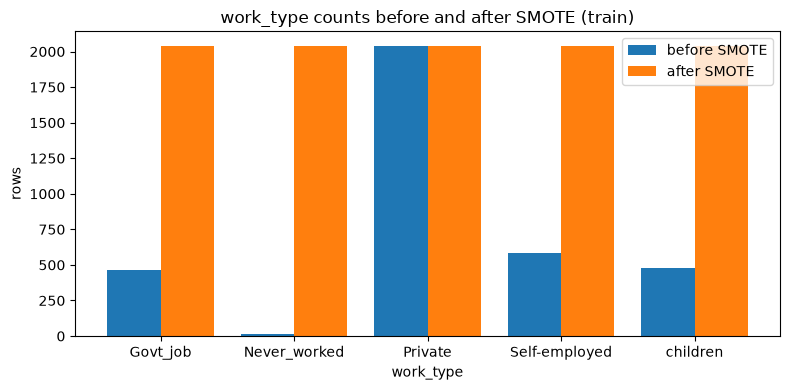

In [7]:
# Before and after chart: work_type counts
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(table))
ax.bar([i - 0.2 for i in x], table["before"], width=0.4, label="before SMOTE")
ax.bar([i + 0.2 for i in x], table["after"], width=0.4, label="after SMOTE")
ax.set_xticks(list(x), table.index)
ax.set_title("work_type counts before and after SMOTE (train)")
ax.set_xlabel("work_type")
ax.set_ylabel("rows")
ax.legend()
plt.tight_layout()
plt.show()

Before SMOTE, work_type ran from Private 2040 down to Never_worked 13. After SMOTE every group has 2040, so 6624 synthetic rows were added. Never_worked gained 2027 rows from only 13 real ones, so those rows are very alike and I treat them with caution.

In [8]:
# D7 how to test step 2 and D6 step 2: a few synthetic rows before repair, in real units
synthetic = balanced[balanced[config.SYNTHETIC_FLAG] == 1]
pipeline.to_real_units(synthetic, state).head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,bmi_missing,gender_Female,gender_Male,ever_married_No,ever_married_Yes,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,work_type,is_synthetic
3576,73.409758,0.240976,0.000000,251.933895,39.832586,0.759024,0.0,1.0,0.0,0.0,1.0,0.00000,1.00000,0.0,0.0,1.0,0.0,Govt_job,1
3577,49.878192,0.000000,0.000000,82.574927,27.323470,0.000000,0.0,0.0,1.0,0.0,1.0,1.00000,0.00000,0.0,0.0,1.0,0.0,Govt_job,1
3578,25.640531,0.000000,0.000000,97.405271,24.999156,0.000000,0.0,0.0,1.0,1.0,0.0,0.19421,0.80579,0.0,1.0,0.0,0.0,Govt_job,1
3579,69.286581,0.000000,0.000000,108.053393,21.523247,0.000000,0.0,1.0,0.0,0.0,1.0,0.00000,1.00000,0.0,0.0,1.0,0.0,Govt_job,1
3580,52.026529,0.000000,0.342176,91.628804,33.365513,0.000000,0.0,0.0,1.0,0.0,1.0,0.00000,1.00000,0.0,0.0,0.0,1.0,Govt_job,1


In [9]:
# D7 how to test step 3: real rows came back unchanged, and new rows are marked 1
real = balanced[balanced[config.SYNTHETIC_FLAG] == 0].drop(columns=[config.SYNTHETIC_FLAG])
pd.testing.assert_frame_equal(real.reset_index(drop=True), prepared.reset_index(drop=True),
                              check_dtype=False)
assert int(balanced[config.SYNTHETIC_FLAG].sum()) == len(balanced) - len(prepared)
print("real rows unchanged; every new row is marked 1")

real rows unchanged; every new row is marked 1


In [10]:
# D7 how to test step 4: dtypes before and after SMOTE
pd.DataFrame({"before": prepared.dtypes.astype(str),
              "after": balanced.dtypes.astype(str).reindex(prepared.columns)})

,before,after
age,float64,float64
hypertension,int64,float64
heart_disease,int64,float64
avg_glucose_level,float64,float64
bmi,float64,float64
stroke,int64,float64
bmi_missing,int64,float64
gender_Female,int64,float64
gender_Male,int64,float64
ever_married_No,int64,float64


In [11]:
# D7 how to test step 4: the same first rows before and after SMOTE
print(prepared.head(3).T)
print(balanced.head(3).T)

                                       0         1         2
age                              0.83641 -1.340103  1.102921
hypertension                           0         0         1
heart_disease                          0         0         0
avg_glucose_level              -0.169525 -0.441514  2.582515
bmi                             1.686225 -0.586777  0.158048
stroke                                 0         0         0
bmi_missing                            0         0         0
gender_Female                          1         0         0
gender_Male                            0         1         1
ever_married_No                        0         1         0
ever_married_Yes                       1         0         1
Residence_type_Rural                   1         1         0
Residence_type_Urban                   0         0         1
smoking_status_Unknown                 1         1         0
smoking_status_formerly smoked         0         0         0
smoking_status_never smo

### D7 how to test step 5: one k value on the signed card

## D8 Repair

In [12]:
# D8 how to test step 1: invalid values before repair
before_repair = pipeline.validity_counts(balanced)
print("0/1 columns, values not 0 or 1:", before_repair["binary"])
print("one hot groups, rows breaking the rule:", before_repair["onehot"])

0/1 columns, values not 0 or 1: {'hypertension': 334, 'heart_disease': 223, 'stroke': 194, 'bmi_missing': 181}
one hot groups, rows breaking the rule: {'gender': 658, 'ever_married': 123, 'Residence_type': 735, 'smoking_status': 1056}


In [13]:
# Repair with the card rule and print what changed
repaired, report = pipeline.repair_after_balance(balanced)
print("0/1 values changed:", report["binary_values_changed"])
print("one hot rows changed:", report["onehot_rows_changed"])

0/1 values changed: {'hypertension': 334, 'heart_disease': 223, 'stroke': 194, 'bmi_missing': 181}
one hot rows changed: {'gender': 658, 'ever_married': 123, 'Residence_type': 735, 'smoking_status': 1056}


In [14]:
# D8 how to test step 2: the same counts after repair must be zero
after_repair = pipeline.validity_counts(repaired)
assert sum(after_repair["binary"].values()) == 0
assert sum(after_repair["onehot"].values()) == 0
print("after repair:", after_repair)

after repair: {'binary': {'hypertension': 0, 'heart_disease': 0, 'stroke': 0, 'bmi_missing': 0}, 'onehot': {'gender': 0, 'ever_married': 0, 'Residence_type': 0, 'smoking_status': 0}}


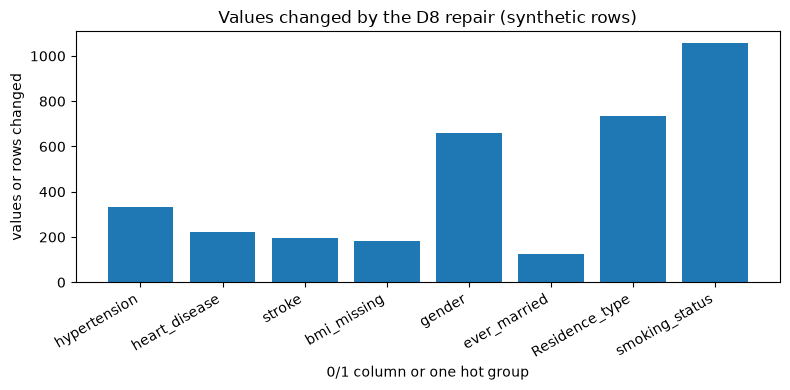

In [15]:
# Chart: values changed by the repair, per column or group
changes = {**report["binary_values_changed"], **report["onehot_rows_changed"]}
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(list(changes), list(changes.values()))
ax.set_title("Values changed by the D8 repair (synthetic rows)")
ax.set_xlabel("0/1 column or one hot group")
ax.set_ylabel("values or rows changed")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

SMOTE blends values, so some 0/1 columns and one hot groups came out in between. Before repair, 334 hypertension, 223 heart_disease, 194 stroke and 181 bmi_missing values weren't 0 or 1, and the one hot groups had 658, 123, 735 and 1056 broken rows. After repair every count is 0.

               before SMOTE  after SMOTE and repair
hypertension         0.0970                  0.0721
heart_disease        0.0526                  0.0348
stroke               0.0470                  0.0305
bmi_missing          0.0386                  0.0244


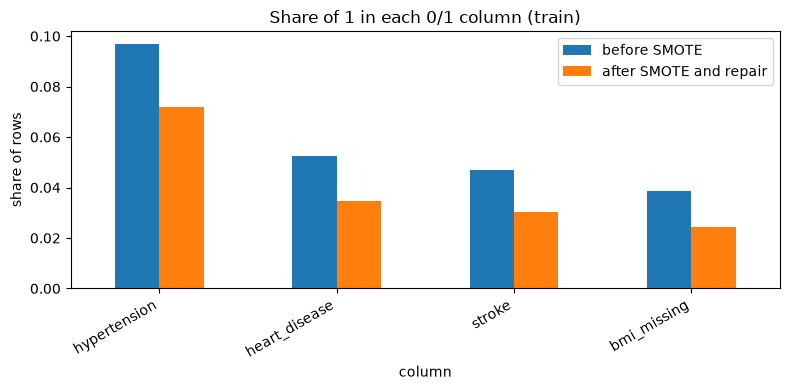

In [16]:
# Before and after chart: share of 1 in each 0/1 column, real rows vs all rows after repair
binary = pipeline.binary_cols(repaired.columns)
shares = pd.DataFrame({"before SMOTE": prepared[binary].mean(),
                       "after SMOTE and repair": repaired[binary].mean()})
print(shares.round(4))
shares.plot.bar(figsize=(8, 4), title="Share of 1 in each 0/1 column (train)")
plt.xlabel("column")
plt.ylabel("share of rows")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

The share of 1s dropped in the balanced file, for example stroke 0.047 to 0.031 and hypertension 0.097 to 0.072. A likely reason is that the new rows copy small groups like children, who rarely have these conditions. So the balanced file is not a picture of real patient rates.

               real rows (before SMOTE)  all rows (after SMOTE and repair)
work_type                                                                 
Govt_job                         0.0542                             0.0402
Never_worked                     0.0000                             0.0000
Private                          0.0475                             0.0475
Self-employed                    0.0752                             0.0613
children                         0.0042                             0.0034


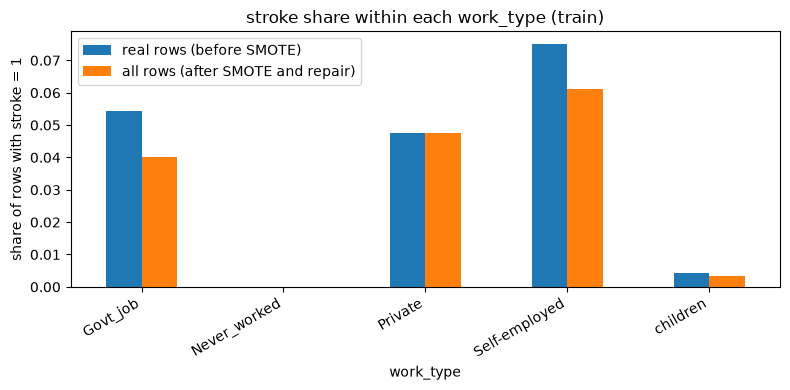

In [17]:
# Before and after chart: stroke share within each work_type, real rows vs all rows after SMOTE
is_real = repaired[config.SYNTHETIC_FLAG] == 0
by_group = pd.DataFrame({
    "real rows (before SMOTE)": repaired[is_real].groupby(config.BALANCE_COL)[config.TARGET].mean(),
    "all rows (after SMOTE and repair)": repaired.groupby(config.BALANCE_COL)[config.TARGET].mean(),
})
print(by_group.round(4))
by_group.plot.bar(figsize=(8, 4), title=f"{config.TARGET} share within each work_type (train)")
plt.xlabel(config.BALANCE_COL)
plt.ylabel(f"share of rows with {config.TARGET} = 1")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Balancing work_type did not balance stroke. Stroke share stayed 0.0475 in Private, where no rows
were added, but fell in every group that grew, for example Self-employed 0.0752 to 0.0613. The new
rows are mostly non stroke, so this file should not be used to estimate real stroke rates.

## D8 Numeric check (option C: range check and distribution comparison)

In [18]:
# Range check: each synthetic value, in real units, inside its work_type's real min and max
real_units = pipeline.to_real_units(repaired, state)
is_new = real_units[config.SYNTHETIC_FLAG] == 1
limits = real_units[~is_new].groupby(config.BALANCE_COL)[config.SCALE_COLUMNS].agg(["min", "max"])
outside = {}
for col in config.SCALE_COLUMNS:
    low = real_units.loc[is_new, config.BALANCE_COL].map(limits[(col, "min")])
    high = real_units.loc[is_new, config.BALANCE_COL].map(limits[(col, "max")])
    values = real_units.loc[is_new, col]
    outside[col] = int(((values < low) | (values > high)).sum())
print("synthetic values outside their work_type's real range:", outside)

synthetic values outside their work_type's real range: {'age': 0, 'avg_glucose_level': 0, 'bmi': 0}


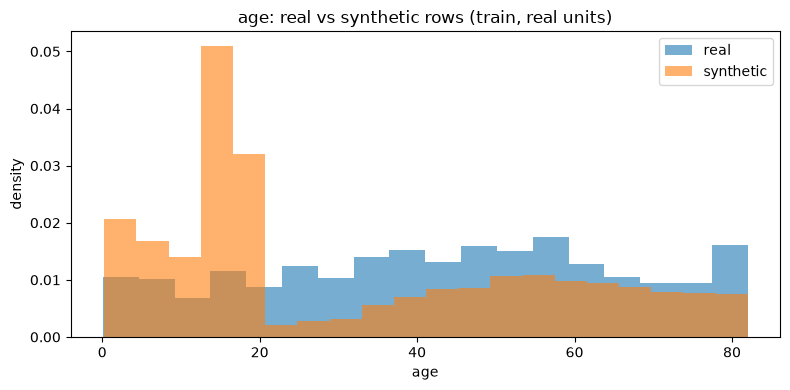

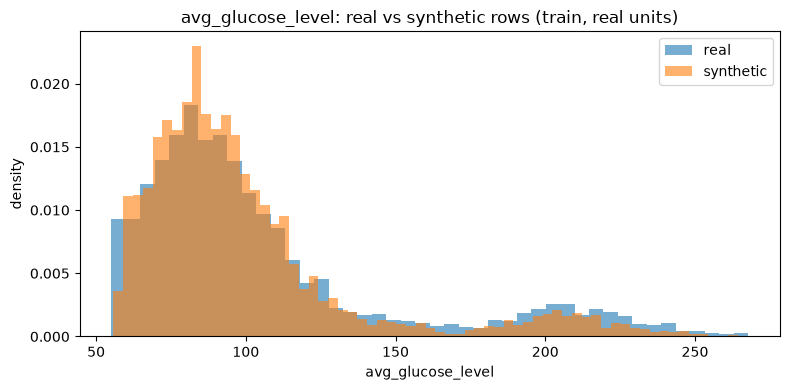

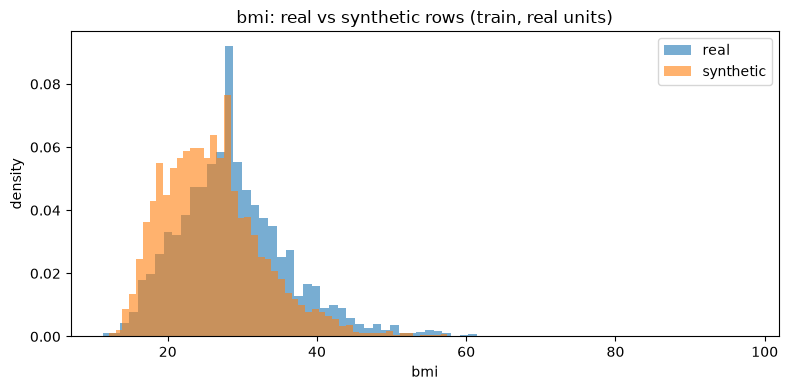

In [19]:
# Distribution comparison: real vs synthetic rows, in real units
for col in config.SCALE_COLUMNS:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(real_units.loc[~is_new, col], bins="auto", alpha=0.6, density=True, label="real")
    ax.hist(real_units.loc[is_new, col], bins="auto", alpha=0.6, density=True, label="synthetic")
    ax.set_title(f"{col}: real vs synthetic rows (train, real units)")
    ax.set_xlabel(col)
    ax.set_ylabel("density")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [20]:
# D6 how to test step 3: summary of real vs synthetic rows, in real units
print(real_units.groupby(is_new.map({False: "real", True: "synthetic"}))[config.SCALE_COLUMNS]
      .describe().T.round(4))

is_synthetic                  real  synthetic
age               count  3576.0000  6624.0000
                  mean     43.1698    31.7685
                  std      22.5162    24.1496
                  min       0.0800     0.2619
                  25%      25.0000    13.9151
                  50%      45.0000    18.0000
                  75%      61.0000    53.8165
                  max      82.0000    82.0000
avg_glucose_level count  3576.0000  6624.0000
                  mean    105.7876    99.9986
                  std      45.1183    37.9710
                  min      55.1200    55.8040
                  25%      76.6900    76.5773
                  50%      91.6400    89.7601
                  75%     114.0125   107.6405
                  max     267.7600   264.2486
bmi               count  3576.0000  6624.0000
                  mean     28.8693    25.9846
                  std       7.7881     6.6691
                  min      11.3000    12.1169
                  25%      23.8000

No synthetic value falls outside its work_type's real range for age, glucose or bmi (0, 0, 0). Synthetic rows are younger on average (age 31.8 vs 43.2) because many come from the children and Never_worked groups. The histograms keep the same overall shape.

## Final train file

In [21]:
# Encode work_type after SMOTE (D4) and check the result
final = pipeline.encode_balance_col(repaired, state)
assert int(final.isna().sum().sum()) == 0
assert all(pd.api.types.is_numeric_dtype(final[c]) for c in final.columns)
print("shape:", final.shape)
print(list(final.columns))

shape: (10200, 23)
['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke', 'bmi_missing', 'gender_Female', 'gender_Male', 'ever_married_No', 'ever_married_Yes', 'Residence_type_Rural', 'Residence_type_Urban', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes', 'work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'is_synthetic']


                         label count  one hot sum
work_type_Govt_job              2040         2040
work_type_Never_worked          2040         2040
work_type_Private               2040         2040
work_type_Self-employed         2040         2040
work_type_children              2040         2040


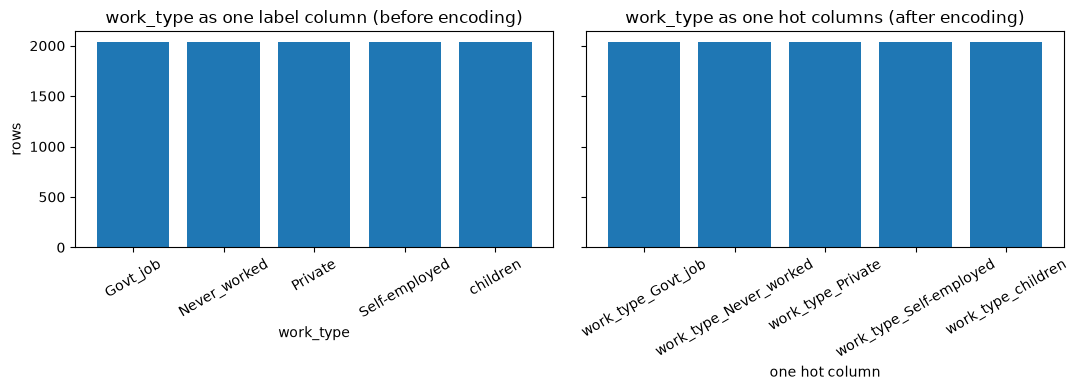

In [22]:
# Before and after chart: work_type label counts vs its one hot column sums
label_counts = repaired[config.BALANCE_COL].value_counts().sort_index()
onehot = [c for c in final.columns if c.startswith(config.BALANCE_COL + "_")]
onehot_sums = final[onehot].sum()
print(pd.DataFrame({"label count": label_counts.values, "one hot sum": onehot_sums.values},
                   index=onehot))
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
axes[0].bar(label_counts.index, label_counts.values)
axes[0].set_title("work_type as one label column (before encoding)")
axes[0].set_xlabel("work_type")
axes[0].set_ylabel("rows")
axes[1].bar(onehot, onehot_sums.values)
axes[1].set_title("work_type as one hot columns (after encoding)")
axes[1].set_xlabel("one hot column")
for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

The final file has 10200 rows and 23 columns. For every work_type the label count equals the one hot column sum (2040 each), so labels and columns agree.

In [23]:
# Before and after table: rows and columns at each stage
pd.DataFrame({"rows": [len(prepared), len(balanced), len(final)],
              "columns": [prepared.shape[1], balanced.shape[1], final.shape[1]]},
             index=["prepared train", "after SMOTE", "final"])

,rows,columns
prepared train,3576,18
after SMOTE,10200,19
final,10200,23


In [24]:
# First rows of the final train file
final.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,bmi_missing,gender_Female,gender_Male,ever_married_No,...,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,is_synthetic
0,0.836410,0,0,-0.169525,1.686225,0,0,1,0,0,...,1,0,0,0,1,0,0,0,0,0
1,-1.340103,0,0,-0.441514,-0.586777,0,0,0,1,1,...,1,0,0,0,0,0,0,0,1,0
2,1.102921,1,0,2.582515,0.158048,0,0,0,1,0,...,0,0,1,0,1,0,0,0,0,0
3,-0.451730,0,0,-0.722371,0.003947,0,0,1,0,0,...,1,0,0,0,0,0,1,0,0,0
4,-1.828708,0,0,-0.885520,-1.639806,0,0,0,1,1,...,1,0,0,0,0,0,0,0,1,0


In [25]:
# Save the final clean train file (Canvas S8)
pipeline.save_csv(final, config.FINAL)
print("saved:", config.FINAL.name)

saved: stroke_clean_final.csv


## Test set: transformed with the train fitted objects, never balanced

In [26]:
# Load the test file and transform it with the objects fitted on train (no fitting)
test = pd.read_csv(config.TEST_RAW)
test_out = pipeline.encode_balance_col(pipeline.transform(test, state), state)
if config.FLAG_SYNTHETIC:
    test_out[config.SYNTHETIC_FLAG] = 0
test_out = test_out[list(final.columns)]
print("rows before:", len(test), "| rows after:", len(test_out))

rows before: 1533 | rows after: 1533


In [27]:
# D4 how to test step 3: test and final train have identical column names in the same order
assert list(test_out.columns) == list(final.columns)
assert int(test_out.isna().sum().sum()) == 0
print("same columns in the same order; no missing values")

same columns in the same order; no missing values


In [28]:
# D3 how to test step 4: test blanks were filled with the train learned value
test_real = pipeline.to_real_units(test_out, state)
for col, value in zip(state["fill_cols"], state["imputer"].statistics_, strict=True):
    filled = test_real.loc[test_out[col + "_missing"] == 1, col]
    assert filled.empty or (filled - value).abs().max() < 1e-9
print("test blanks hold the train learned fill values")

test blanks hold the train learned fill values


In [29]:
# D5 how to test step 3: range of the scaled test columns
test_out[config.SCALE_COLUMNS].agg(["min", "max"]).round(4)

,age,avg_glucose_level,bmi
min,-1.9140,-1.1198,-2.3846
max,1.7248,3.6787,4.6142


In [30]:
# Save the transformed test file
pipeline.save_csv(test_out, config.TEST_TRANSFORMED)
print("saved:", config.TEST_TRANSFORMED.name)

saved: stroke_test_transformed.csv


## How this dataset could be used to solve an ML problem

This data could train a classifier that flags patients at higher stroke risk from age, glucose, bmi, hypertension, heart disease and lifestyle columns, so a clinic could pick who gets a follow up screening. I'd train on the train file and judge only on the untouched 1533 row test file, using recall on stroke cases, because missing a stroke is worse than a false alarm. is_synthetic lets me check whether the synthetic rows help or hurt.